In [21]:
# ============================================
# CELL 1 - Install Required Libraries
# ============================================

# Run this only once
# !pip install librosa soundfile scikit-learn seaborn joblib

In [22]:
# ============================================
# CELL 2 - Imports
# ============================================

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

In [23]:
# ============================================
# CELL 3 - Dataset Path
# ============================================

DATASET_PATH = r"C:\Users\HP\Downloads\birdsound_recognition\dataset"

print("Dataset Path:", DATASET_PATH)

# Expected Folder Structure
#
# dataset/
# ├── crow/
# ├── peacock/
# ├── cuckoo/
# ├── kingfisher/
# ├── bluejay/
# └── noise/

Dataset Path: C:\Users\HP\Downloads\birdsound_recognition\dataset


In [24]:
# ============================================
# CELL 4 - Feature Extraction Function
# ============================================

def extract_features(file_path):

    try:
        # Load Audio
        audio, sr = librosa.load(file_path, sr=22050)

        features = []

        # =====================================
        # MFCC Features
        # =====================================
        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=20
        )

        # =====================================
        # Spectral Centroid
        # =====================================
        spectral_centroid = librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )

        # =====================================
        # Spectral Rolloff
        # =====================================
        spectral_rolloff = librosa.feature.spectral_rolloff(
            y=audio,
            sr=sr
        )

        # =====================================
        # Zero Crossing Rate
        # =====================================
        zcr = librosa.feature.zero_crossing_rate(audio)

        # =====================================
        # Chroma Features
        # =====================================
        chroma = librosa.feature.chroma_stft(
            y=audio,
            sr=sr
        )

        # =====================================
        # Statistical Aggregation Function
        # =====================================
        def add_statistics(feature):
            features.extend([
                np.mean(feature),
                np.std(feature),
                np.min(feature),
                np.max(feature)
            ])

        # Add MFCC statistics
        for mfcc in mfccs:
            add_statistics(mfcc)

        # Add other features
        add_statistics(spectral_centroid)
        add_statistics(spectral_rolloff)
        add_statistics(zcr)

        for ch in chroma:
            add_statistics(ch)

        return features

    except Exception as e:
        print(f"Error processing {file_path}")
        print(e)
        return None

In [25]:
# ============================================
# CELL 5 - Load Dataset and Extract Features
# ============================================

X = []
y = []

classes = os.listdir(DATASET_PATH)

print("Classes Found:", classes)

for label in classes:

    folder_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(folder_path):
        continue

    print(f"\nProcessing Class: {label}")

    for file_name in tqdm(os.listdir(folder_path)):

        if file_name.endswith(".mp3") or file_name.endswith(".wav"):

            file_path = os.path.join(folder_path, file_name)

            features = extract_features(file_path)

            if features is not None:
                X.append(features)
                y.append(label)

print("\nFeature Extraction Completed")
print("Total Samples:", len(X))

Classes Found: ['bluejay', 'crow', 'cuckoo', 'kingfisher', 'noise']

Processing Class: bluejay


  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 60%|██████    | 60/100 [00:41<00:08,  4.96it/s]c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 100/100 [00:52<00:00,  1.92it/s]



Processing Class: crow


100%|██████████| 100/100 [00:53<00:00,  1.87it/s]



Processing Class: cuckoo


...


Processing Class: kingfisher


100%|██████████| 69/69 [00:20<00:00,  3.33it/s]



Processing Class: noise


100%|██████████| 30/30 [00:01<00:00, 20.54it/s]


Feature Extraction Completed
Total Samples: 347


In [26]:
# ============================================
# CELL 6 - Convert to NumPy Arrays
# ============================================

X = np.array(X)
y = np.array(y)

print("Feature Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Shape: (347, 140)
Labels Shape: (347,)


In [27]:
# ============================================
# CELL 7 - Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 277
Testing Samples: 70


In [28]:
# ============================================
# CELL 8 - Feature Scaling
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# ============================================
# CELL 9 - Train SVM Model
# ============================================

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

print("SVM Training Completed")

SVM Training Completed


In [30]:
# ============================================
# CELL 10 - Train KNN Model
# ============================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

print("KNN Training Completed")

KNN Training Completed


In [31]:
# ============================================
# CELL 11 - Train Random Forest Model
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Training Completed")

Random Forest Training Completed


In [32]:
# ============================================
# CELL 12 - Evaluation Function
# ============================================

def evaluate_model(model, model_name):

    y_pred = model.predict(X_test)

    print("="*60)
    print(model_name)
    print("="*60)

    accuracy = accuracy_score(y_test, y_pred)

    print("\nAccuracy:", accuracy)

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=np.unique(y),
        yticklabels=np.unique(y)
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

SVM Classifier

Accuracy: 0.8142857142857143

Classification Report:

              precision    recall  f1-score   support

     bluejay       0.74      0.85      0.79        20
        crow       1.00      0.90      0.95        20
      cuckoo       0.56      0.50      0.53        10
  kingfisher       0.79      0.79      0.79        14
       noise       1.00      1.00      1.00         6

    accuracy                           0.81        70
   macro avg       0.82      0.81      0.81        70
weighted avg       0.82      0.81      0.81        70



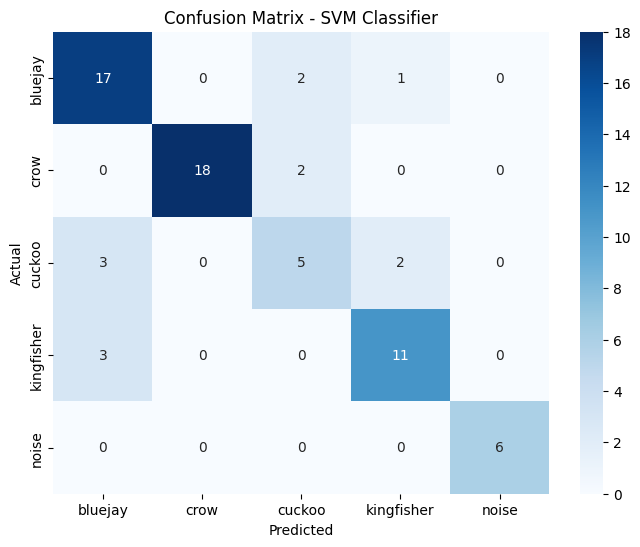

In [33]:
# ============================================
# CELL 13 - Evaluate SVM
# ============================================

evaluate_model(svm_model, "SVM Classifier")

KNN Classifier

Accuracy: 0.7428571428571429

Classification Report:

              precision    recall  f1-score   support

     bluejay       0.71      0.85      0.77        20
        crow       0.84      0.80      0.82        20
      cuckoo       0.40      0.20      0.27        10
  kingfisher       0.69      0.79      0.73        14
       noise       1.00      1.00      1.00         6

    accuracy                           0.74        70
   macro avg       0.73      0.73      0.72        70
weighted avg       0.72      0.74      0.73        70



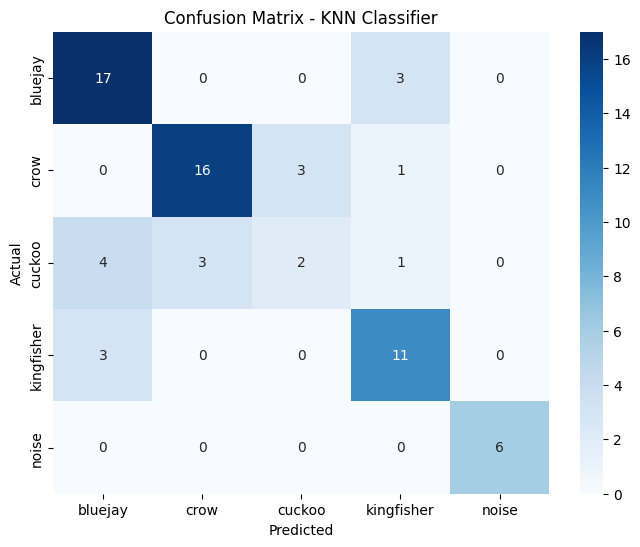

In [34]:
# ============================================
# CELL 14 - Evaluate KNN
# ============================================

evaluate_model(knn_model, "KNN Classifier")

Random Forest Classifier

Accuracy: 0.7714285714285715

Classification Report:

              precision    recall  f1-score   support

     bluejay       0.75      0.90      0.82        20
        crow       0.89      0.85      0.87        20
      cuckoo       0.60      0.30      0.40        10
  kingfisher       0.62      0.71      0.67        14
       noise       1.00      1.00      1.00         6

    accuracy                           0.77        70
   macro avg       0.77      0.75      0.75        70
weighted avg       0.77      0.77      0.76        70



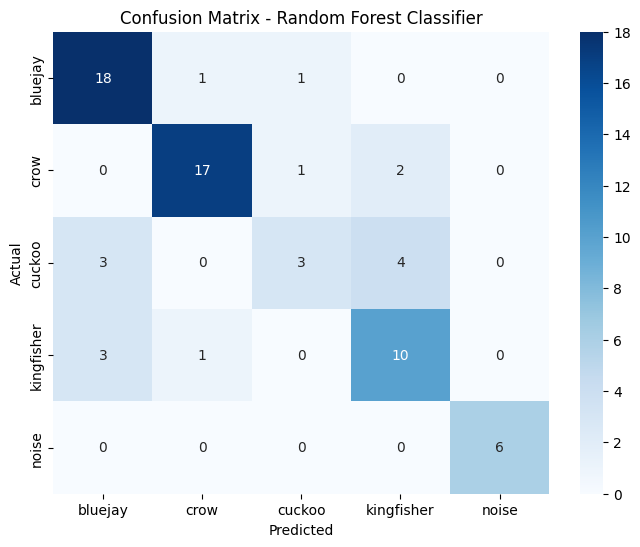

In [35]:
# ============================================
# CELL 15 - Evaluate Random Forest
# ============================================

evaluate_model(rf_model, "Random Forest Classifier")

In [36]:
# ============================================
# CELL 16 - Feature Importance using Random Forest
# ============================================

importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature_Index': np.arange(len(importance)),
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

     Feature_Index  Importance
9                9    0.051010
21              21    0.050487
58              58    0.024478
1                1    0.022005
23              23    0.020813
13              13    0.020618
73              73    0.018304
77              77    0.017220
6                6    0.016767
94              94    0.016424
75              75    0.015738
3                3    0.015278
2                2    0.015209
110            110    0.013977
98              98    0.013875
102            102    0.013702
5                5    0.013050
30              30    0.012789
33              33    0.012668
10              10    0.012236


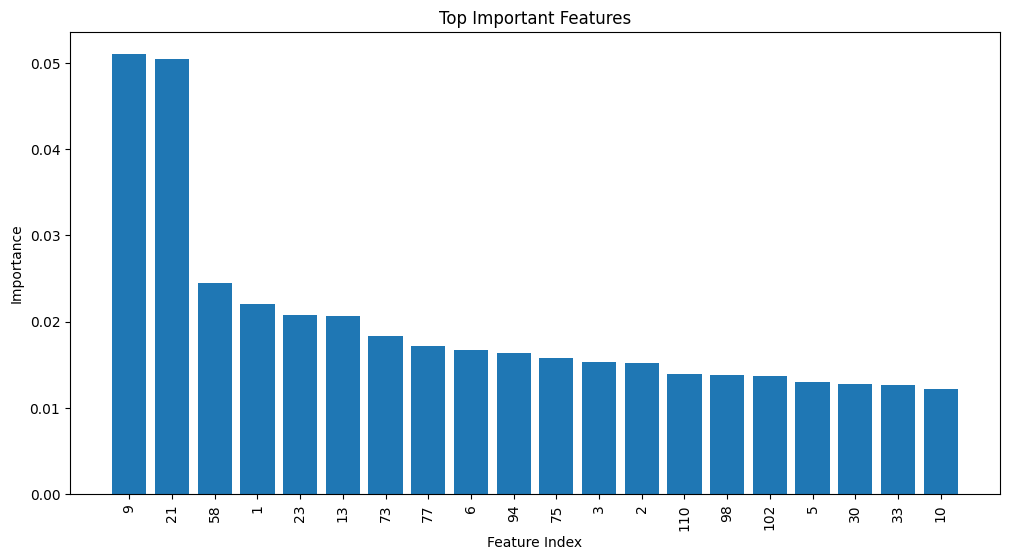

In [37]:
# ============================================
# CELL 17 - Plot Top Important Features
# ============================================

top_n = 20

top_features = importance_df.head(top_n)

plt.figure(figsize=(12,6))

plt.bar(
    top_features['Feature_Index'].astype(str),
    top_features['Importance']
)

plt.xticks(rotation=90)

plt.title("Top Important Features")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.show()

In [42]:
# ============================================
# CELL 18 - Predict Single Audio File
# ============================================

test_audio = r"C:\Users\HP\Downloads\birdsound_recognition\dataset\noise\noise_3.wav"

features = extract_features(test_audio)

features = np.array(features).reshape(1, -1)

features = scaler.transform(features)

prediction = svm_model.predict(features)

print("Predicted Bird:", prediction[0])

Predicted Bird: noise


In [39]:
# ============================================
# CELL 19 - Save Model
# ============================================

import joblib

joblib.dump(svm_model, "bird_svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully
